# NSCLC Datset Investigation

## Load Dataset

In [2]:
import pandas as pd
import scanpy as sc
from utils.io import read_anndata
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dask import array as da
from tqdm.dask import TqdmCallback

from utils.cellxgene import get_cxg_url
from utils.io import read_anndata


url = get_cxg_url(
    collection_id="edb893ee-4066-4128-9aec-5eb2b03f8287",
    dataset_id="232f6a5a-a04c-4758-a6e8-88ab2e3a6e69"
)

dataset_name = 'Salcher2022'
file_path = f'data/{dataset_name}.h5ad'

if not Path(file_path).exists():
    !curl {url} > {file_path}


adata = read_anndata(
    file_path,
    # X='X',
    obs='obs',
    var='var',
    obsm='obsm',
)

/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Get URL for CxG collection ID "edb893ee-4066-4128-9aec-5eb2b03f8287" and dataset ID "232f6a5a-a04c-4758-a6e8-88ab2e3a6e69"
URL: https://datasets.cellxgene.cziscience.com/b237a148-4472-4ba0-b8b3-6dd056c0457a.h5ad
dask: False, backed: False
Read slot "obs", store as "obs"...
Read slot "var", store as "var"...
Read slot "obsm", store as "obsm"...


## Dataset Complexity
### Tissues

In [3]:
adata.obs["tissue"].unique()

['lung', 'brain', 'lymph node', 'pleural effusion', 'liver', 'adrenal tissue']
Categories (6, object): ['lymph node', 'pleural effusion', 'brain', 'lung', 'liver', 'adrenal tissue']

Sample size of the tissues:

In [4]:
sample_size = adata.obs["tissue"].value_counts()
sample_size

tissue
lung                792451
lymph node           55125
pleural effusion     21421
brain                20295
liver                 2366
adrenal tissue         638
Name: count, dtype: int64

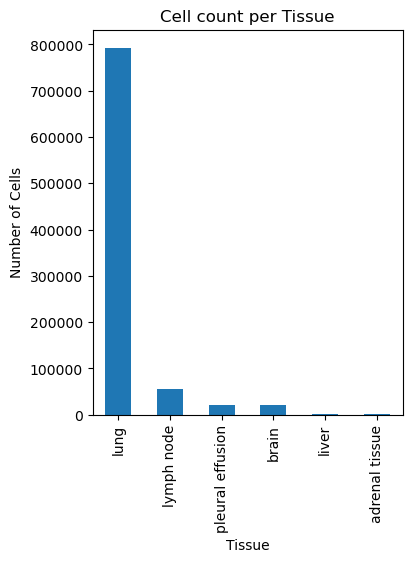

In [5]:
plt.figure(figsize=(4, 5))
sample_size.plot(kind='bar')
plt.title("Cell count per Tissue")
plt.xlabel("Tissue")
plt.ylabel("Number of Cells")
plt.xticks(rotation=90)
plt.show()

### Number of Cells and Genes

In [6]:
adata

AnnData object with n_obs × n_vars = 892296 × 17797
    obs: 'sample', 'uicc_stage', 'ever_smoker', 'age', 'donor_id', 'origin', 'dataset', 'ann_fine', 'cell_type_predicted', 'doublet_status', 'leiden', 'n_genes_by_counts', 'total_counts', 'total_counts_mito', 'pct_counts_mito', 'ann_coarse', 'cell_type_tumor', 'tumor_stage', 'TP53_mutation', 'ALK_mutation', 'BRAF_mutation', 'ERBB2_mutation', 'KRAS_mutation', 'ROS_mutation', 'origin_fine', 'study', 'platform', 'cell_type_major', 'suspension_type', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'tissue_type', 'EGFR_mutation', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'is_highly_variable', 'mito', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_cou

### Cell Types

In [7]:
adata.obs["cell_type"].nunique()

33

## Batch Complexity
### Number of Batches

batches = dataset according to the paper

In [8]:
adata.obs["dataset"].nunique()

21

### Batch Size Imbalance

In [9]:
batch_size = adata.obs["dataset"].value_counts().sort_values(ascending=False)
mean = np.mean(batch_size)
std = np.std(batch_size)
min_val = batch_size.min()
max_val = batch_size.max()
print(f"Mean batch size: {mean:.2f}")
print(f"Standard deviation: {std:.2f}")
print(f"Minimum batch size: {min_val}")
print(f"Maximum batch size: {max_val}")

Mean batch size: 42490.29
Standard deviation: 43974.13
Minimum batch size: 3538
Maximum batch size: 175526


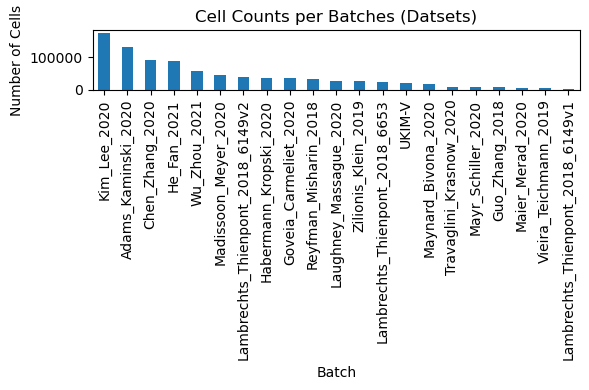

In [10]:
plt.figure(figsize=(6, 4))
batch_size.plot(kind='bar')
plt.title("Cell Counts per Batches (Datsets)")
plt.xlabel("Batch")
plt.ylabel("Number of Cells")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Nested Batches

In [11]:
adata.obs[["dataset", "donor_id"]].drop_duplicates().value_counts("dataset")

dataset
Adams_Kaminski_2020                 46
Kim_Lee_2020                        44
Wu_Zhou_2021                        42
Maier_Merad_2020                    29
Maynard_Bivona_2020                 29
Laughney_Massague_2020              14
Guo_Zhang_2018                      13
Chen_Zhang_2020                     11
Habermann_Kropski_2020              10
Mayr_Schiller_2020                  10
Reyfman_Misharin_2018                8
Goveia_Carmeliet_2020                7
Zilionis_Klein_2019                  7
He_Fan_2021                          5
Madissoon_Meyer_2020                 5
Vieira_Teichmann_2019                4
Lambrechts_Thienpont_2018_6149v2     3
Travaglini_Krasnow_2020              3
Lambrechts_Thienpont_2018_6653       3
UKIM-V                               3
Lambrechts_Thienpont_2018_6149v1     2
Name: count, dtype: int64

In [12]:
adata.obs[["dataset", "donor_id"]].drop_duplicates().value_counts("donor_id")

donor_id
Zilionis_Klein_2019_patient_7    1
Adams_Kaminski_2020_001C         1
Adams_Kaminski_2020_002C         1
Adams_Kaminski_2020_003C         1
Adams_Kaminski_2020_8CO          1
                                ..
Adams_Kaminski_2020_133C         1
Adams_Kaminski_2020_137C         1
Adams_Kaminski_2020_137CO        1
Adams_Kaminski_2020_152CO        1
Adams_Kaminski_2020_153CO        1
Name: count, Length: 298, dtype: int64

dataset:donor is in 1:N relationship -> nested batches?

### Number and Size of Samples

In [13]:
adata.obs["sample"].nunique()

505

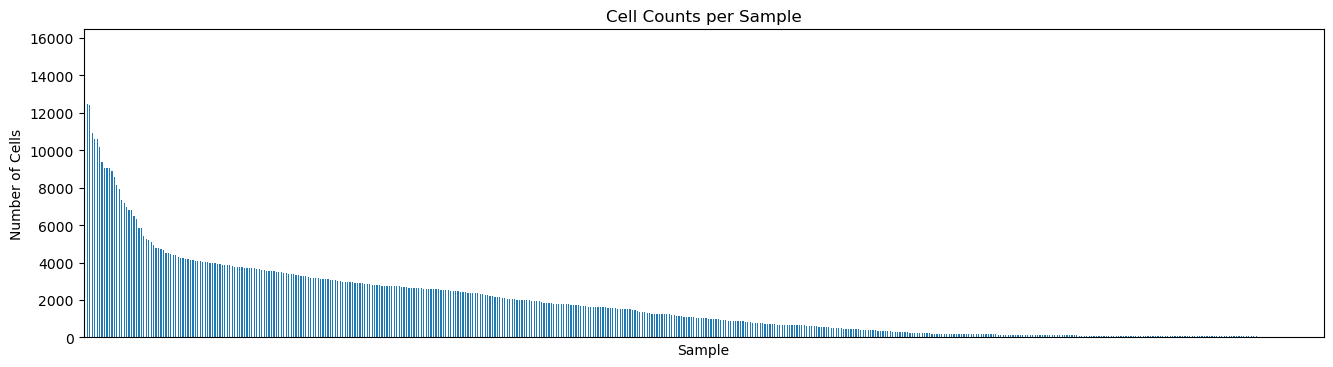

In [14]:
sample_size = adata.obs["sample"].value_counts()
plt.figure(figsize=(16, 4))
sample_size.plot(kind='bar')
plt.title("Cell Counts per Sample")
plt.xlabel("Sample")
plt.ylabel("Number of Cells")
plt.xticks([])
plt.show()

### Number of Donors

In [15]:
adata.obs["donor_id"].nunique()

298

### Number of Cohorts

In [16]:
adata.obs["study"].nunique()

19

In [17]:
adata.obs[["dataset", "study"]].drop_duplicates().value_counts("study")

study
Lambrechts_Thienpont_2018    3
Chen_Zhang_2020              1
Adams_Kaminski_2020          1
Goveia_Carmeliet_2020        1
Guo_Zhang_2018               1
He_Fan_2021                  1
Habermann_Kropski_2020       1
Kim_Lee_2020                 1
Laughney_Massague_2020       1
Madissoon_Meyer_2020         1
Maier_Merad_2020             1
Maynard_Bivona_2020          1
Mayr_Schiller_2020           1
Reyfman_Misharin_2018        1
Travaglini_Krasnow_2020      1
UKIM-V                       1
Vieira_Teichmann_2019        1
Wu_Zhou_2021                 1
Zilionis_Klein_2019          1
Name: count, dtype: int64

In [19]:
adata.obs.query("study=='Lambrechts_Thienpont_2018'")["dataset"].unique()

['Lambrechts_Thienpont_2018_6149v1', 'Lambrechts_Thienpont_2018_6149v2', 'Lambrechts_Thienpont_2018_6653']
Categories (21, object): ['Adams_Kaminski_2020', 'Chen_Zhang_2020', 'Goveia_Carmeliet_2020', 'Guo_Zhang_2018', ..., 'UKIM-V', 'Vieira_Teichmann_2019', 'Wu_Zhou_2021', 'Zilionis_Klein_2019']

In [ ]:
check in the paper why they have three diff dataset in lambrechts_Thienpont

## Annotation Quality
### Resolution of Annotation

Q: Can't find the marker genes, the table is not readable using LLM :(

Cananonical markergenes

### Granularity of Cell Types

In [32]:
adata

AnnData object with n_obs × n_vars = 892296 × 17797
    obs: 'sample', 'uicc_stage', 'ever_smoker', 'age', 'donor_id', 'origin', 'dataset', 'ann_fine', 'cell_type_predicted', 'doublet_status', 'leiden', 'n_genes_by_counts', 'total_counts', 'total_counts_mito', 'pct_counts_mito', 'ann_coarse', 'cell_type_tumor', 'tumor_stage', 'TP53_mutation', 'ALK_mutation', 'BRAF_mutation', 'ERBB2_mutation', 'KRAS_mutation', 'ROS_mutation', 'origin_fine', 'study', 'platform', 'cell_type_major', 'suspension_type', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'tissue_type', 'EGFR_mutation', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'is_highly_variable', 'mito', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_cou

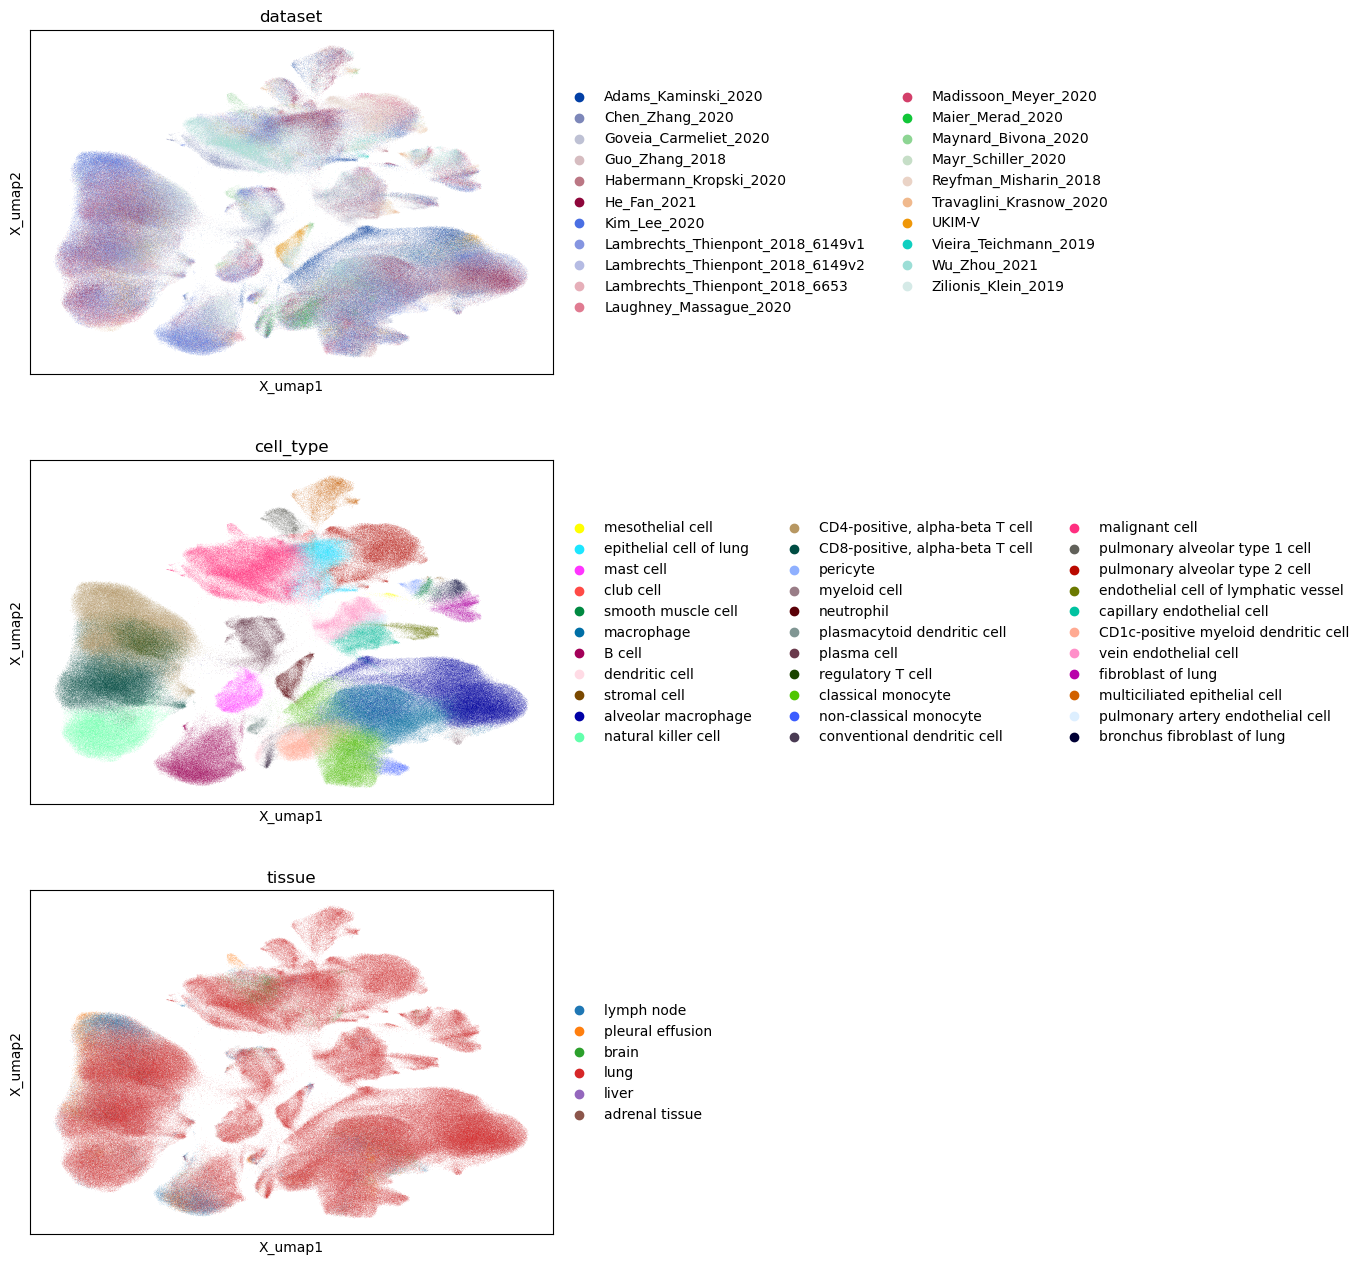

In [20]:
sc.pl.embedding(
    adata,
    basis='X_umap',
    color=['dataset',
           'cell_type',
           'tissue'], ncols=1)

In [ ]:
double check with hlca annotation of lv 1 2 3 blahblah

did they actually take brain tissue or lung cancer from brain

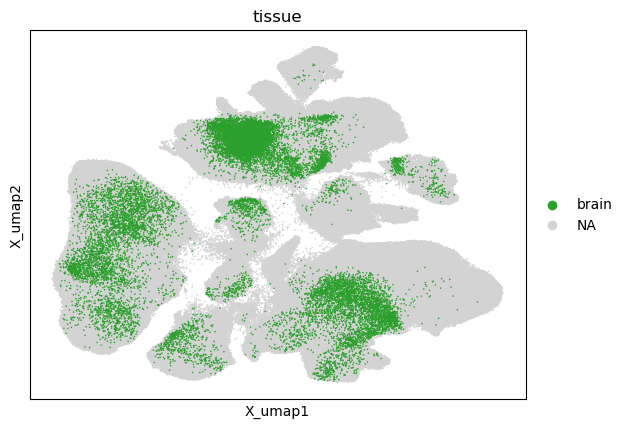

In [22]:
sc.pl.embedding(
    adata,
    basis='X_umap',
    color=[
           'tissue'], groups='brain', size=5, ncols=1)

In [ ]:
bar plot cell type vs tissues

In [ ]:
----

In [ ]:
check the shape of the var and investigate genes : how many unique genes do we have per dataset

## Metadata Completeness
### Anatomical Location

Samples of NSCLC tumor tissues and matched adjacent normal lung tissues (more than 5 cm distance to the tumor) were obtained from surgical specimens of patients

### Existence of Embeddings

In [36]:
adata.obsm

AxisArrays with keys: X_scANVI, X_scVI, X_umap